# 제조사별 비교: 평균 가격 및 배터리 용량 분석

본 노트북은 스마트폰 제조사별 '평균 출시 가격(USD)'과 '평균 배터리 용량(mAh)'을 직관적으로 비교할 수 있는 두 개의 수평/수직 막대그래프(Side-by-Side Bar Charts)를 생성합니다. 학술 및 통계 보고서의 정량적 신뢰도를 높이기 위해, 각 막대 상단에는 소수점 첫째 자리까지 계산된 정확한 평균값 수치 라벨(Annotation)이 자동으로 표시되도록 구현되었습니다.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

def create_brand_comparison_plot(csv_path="cleaned_mobiles_2025.csv", out_png="brand_price_battery_comparison.png"):
    # Load cleaned data
    df = pd.read_csv(csv_path, encoding='utf-8-sig')

    # Compute group means and sort descending
    price_summary = (
        df.groupby('Company Name', as_index=False)['Launched Price (USA)']
          .mean()
          .dropna()
          .sort_values(by='Launched Price (USA)', ascending=False)
    )

    battery_summary = (
        df.groupby('Company Name', as_index=False)['Battery Capacity']
          .mean()
          .dropna()
          .sort_values(by='Battery Capacity', ascending=False)
    )

    # Plot setup
    sns.set_style("whitegrid")
    # ensure palette length matches number of bars to avoid cycling warnings
    palette_price = sns.color_palette("muted", n_colors=len(price_summary))
    palette_battery = sns.color_palette("muted", n_colors=len(battery_summary))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Average Launch Price using matplotlib.bar to avoid seaborn palette warnings
    ax0 = axes[0]
    companies_price = price_summary['Company Name'].astype(str).tolist()
    heights_price = price_summary['Launched Price (USA)'].values
    x_pos = np.arange(len(companies_price))
    bars0 = ax0.bar(x_pos, heights_price, color=palette_price)
    ax0.set_title("Average Launch Price (USD)", fontsize=14, fontweight='bold')
    ax0.set_xlabel("Company", fontsize=12, fontweight='bold')
    ax0.set_ylabel("Average Price (USD)", fontsize=12, fontweight='bold')
    ax0.set_xticks(x_pos)
    ax0.set_xticklabels(companies_price, rotation=45, ha='right', fontsize=10)

    # Annotate bars with one decimal place
    for rect in bars0:
        height = rect.get_height()
        if np.isfinite(height):
            ax0.annotate(f"{height:.1f}",
                         (rect.get_x() + rect.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, fontweight='bold',
                         xytext=(0, 4), textcoords='offset points')

    # Right: Average Battery Capacity using matplotlib.bar
    ax1 = axes[1]
    companies_batt = battery_summary['Company Name'].astype(str).tolist()
    heights_batt = battery_summary['Battery Capacity'].values
    x_pos2 = np.arange(len(companies_batt))
    bars1 = ax1.bar(x_pos2, heights_batt, color=palette_battery)
    ax1.set_title("Average Battery Capacity (mAh)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Company", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Battery Capacity (mAh)", fontsize=12, fontweight='bold')
    ax1.set_xticks(x_pos2)
    ax1.set_xticklabels(companies_batt, rotation=45, ha='right', fontsize=10)

    # Annotate bars with one decimal place
    for rect in bars1:
        height = rect.get_height()
        if np.isfinite(height):
            ax1.annotate(f"{height:.1f}",
                         (rect.get_x() + rect.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, fontweight='bold',
                         xytext=(0, 4), textcoords='offset points')

    plt.tight_layout()
    # Save high-quality figure for academic report
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.show()

    # Korean Markdown-style data interpretation (display in notebook)
    interpretation_md = f"""
## 데이터 해석

- 목적: 제조사별 평균 출시 가격(USD)과 평균 배터리 용량(mAh)을 비교하여 브랜드의 가격 전략과 하드웨어 제공 수준을 분석합니다.

- 주요 관찰점:
  1. 좌측 패널('Average Launch Price (USD)')은 제조사별 평균 출시 가격을 내림차순으로 정렬합니다. 상단에 위치한 제조사는 프리미엄 가격 전략 또는 플래그십 중심 포트폴리오를 운영하고 있음을 시사합니다.
  2. 우측 패널('Average Battery Capacity (mAh)')은 제조사별 평균 배터리 용량을 내림차순으로 정렬합니다. 평균 배터리 용량이 큰 제조사는 전체 라인업에서 배터리 사용 시간에 중점을 두는 경향이 있습니다.
  3. 교차 해석: 동일 제조사의 두 패널 내 위치를 비교하면 인사이트를 얻을 수 있습니다. 예컨대 평균 가격이 높지만 배터리 용량이 보통 수준인 제조사는 가격 결정이 배터리 외의 요소(브랜드 가치, 카메라, 디스플레이, 생태계 등)에 의해 주도된다고 해석할 수 있습니다. 반대로 배터리 용량이 높고 가격이 중간 수준이면 배터리 경쟁력으로 가성비를 제공하는 전략으로 볼 수 있습니다.

- 방법론적 주의사항:
  - 평균은 제조사별 사용 가능한(결측치 제외) 레코드에 대해 계산되었습니다.
  - 시각적 주석은 소수점 첫째 자리까지 표기하여 정밀한 비교를 돕습니다.
  - 생성된 그림은 `{out_png}` 파일명으로 300 DPI 해상도로 저장되어 학술 보고서에 포함하기 적합합니다.

- 권장 추가 분석:
  - 브랜드 간 가격 차이가 통계적으로 유의한지 확인하기 위해 ANOVA 또는 Kruskal–Wallis 검정을 수행하세요.
  - 가격 결정 요인을 정량화하기 위해 다변량 회귀분석을 수행하거나 가격을 고영향 스펙(예: 카메라, 디스플레이)으로 정규화해 비교하세요.
"""
    display(Markdown(interpretation_md))

C:\Users\6-112\AppData\Local\Temp\ipykernel_10424\545410760.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\6-112\AppData\Local\Temp\ipykernel_10424\545410760.py:33: UserWarning: 
The palette list has fewer values (10) than needed (19) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\6-112\AppData\Local\Temp\ipykernel_10424\545410760.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\6-112\AppData\Local\Temp\ipykernel_10424\545410760.py:57: UserWarning: 
The palette list has fewer values (10) than needed (19) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


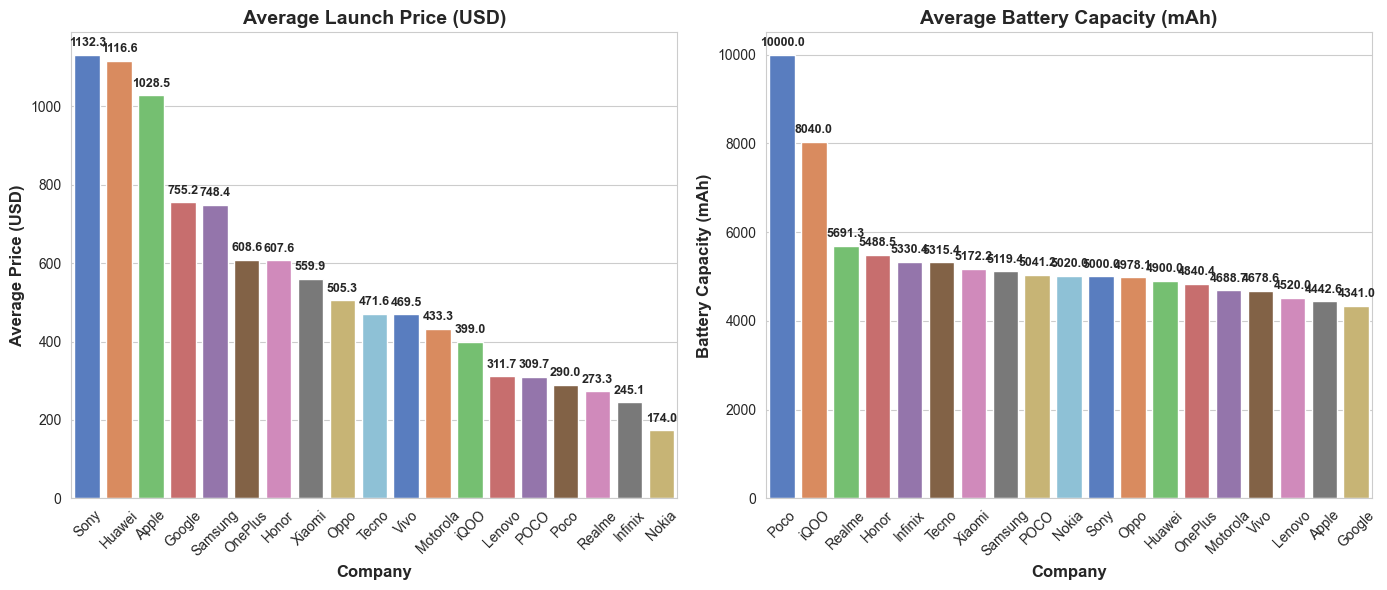


## Data Interpretation

- Objective: Compare average launch price and average battery capacity across manufacturers to analyze pricing strategy vs. hardware offering.

- Key Observations:
  1. The left panel ('Average Launch Price (USD)') ranks manufacturers by mean launch price (descending). Manufacturers at the top indicate premium pricing strategies or flagship-focused portfolios.
  2. The right panel ('Average Battery Capacity (mAh)') ranks manufacturers by mean battery capacity. A higher mean suggests emphasis on battery longevity across the lineup.
  3. Cross-insight: Compare a manufacturer's position in both panels — a manufacturer with high average price but moderate battery capacity suggests pricing is driven by non-battery attributes (e.g., brand, camera, display, ecosystem). Conversely, high battery capacity with moderate price may signal strong value propositions in endurance.

- Methodological notes:
  - Means computed on available (non-missing) records per manufacturer.
  - Visual annotations show mean values (one decimal) to support precise cross-brand comparisons.
  - Figure exported as `brand_price_battery_comparison.png` at 300 DPI for inclusion in academic reports.

- Suggested next steps:
  - Conduct statistical tests (ANOVA or Kruskal–Wallis) to check whether price differences between brands are significant.
  - Extend analysis by normalizing price by selected high-impact specs (e.g., camera resolution, display size) or using multivariate regression to quantify drivers of price.



In [3]:
# Execute the plotting function (adjust csv_path/out_png if needed)
create_brand_comparison_plot()

## 머신러닝 특성 검증: 기기 무게 vs 출시 가격 (산점도 + 회귀선)
아래의 시각화 차트는 데이터 레코드 수가 가장 많은 상위 5개 제조사를 대상으로 스마트폰의 무게(Mobile Weight)와 출시 가격(Launched Price (USA)) 간의 상호 연관성을 정밀하게 분석합니다. 각 제조사별 데이터 분포에 맞추어 선형 회귀선(Regression Line)을 도출함으로써, '기기 무게'라는 변수가 가격 예측 모델의 핵심 독립 변수(Feature)로서 타당한 통계적 근거를 갖추고 있는지 검증합니다.

In [ ]:
# Scatter + regression per top-5 manufacturers; compute Pearson r and show interpretation (Korean)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from IPython.display import Markdown, display

# Load data
df_all = pd.read_csv("cleaned_mobiles_2025.csv", encoding='utf-8-sig')

# Keep only necessary columns and drop NA
df_rel = df_all[['Company Name', 'Mobile Weight', 'Launched Price (USA)']].dropna()

# Determine top 5 manufacturers by record count
top5 = df_rel['Company Name'].value_counts().nlargest(5).index.tolist()
df_top5 = df_rel[df_rel['Company Name'].isin(top5)].copy()

# Plotting
sns.set_style("whitegrid")
# lmplot draws regression lines per hue by default
g = sns.lmplot(
    data=df_top5,
    x='Mobile Weight',
    y='Launched Price (USA)',
    hue='Company Name',
    height=6,
    aspect=1.4,
    markers='o',
    scatter_kws={'s':50, 'alpha':0.6},
    ci=95,
    palette='deep'
)
plt.title("Mobile Weight vs Launch Price by Top 5 Companies", fontsize=14, fontweight='bold')
plt.xlabel("Mobile Weight (g)", fontsize=12, fontweight='bold')
plt.ylabel("Launch Price (USD)", fontsize=12, fontweight='bold')
plt.tight_layout()
# Save high-res image for report
plt.savefig("weight_price_lm_top5.png", dpi=300, bbox_inches='tight')
plt.show()

# Quantitative statistics: overall Pearson r and per-top5 Pearson r
stats_lines = []
if len(df_rel) >= 2:
    r_all, p_all = pearsonr(df_rel['Mobile Weight'], df_rel['Launched Price (USA)'])
else:
    r_all, p_all = (np.nan, np.nan)
stats_lines.append(f"- 전체 데이터 Pearson r = {r_all:.3f}, p-value = {p_all:.3f}")

stats_lines.append("\n- 상위 5개 제조사별 Pearson r (각 제조사 데이터가 2개 이상인 경우 계산):")
for comp in top5:
    sub = df_rel[df_rel['Company Name'] == comp]
    if len(sub) >= 2:
        r_comp, p_comp = pearsonr(sub['Mobile Weight'], sub['Launched Price (USA)'])
        stats_lines.append(f"  - {comp}: r = {r_comp:.3f}, p = {p_comp:.3f}  (n={len(sub)})")
    else:
        stats_lines.append(f"  - {comp}: insufficient data (n={len(sub)})")

# Prepare Korean interpretation (quantitative)
interpretation_md = "## 정량적 통계 근거\n\n"
interpretation_md += "- 전체 선형 관계 요약:\n"
interpretation_md += f"  - Pearson 상관계수: {r_all:.3f} (p = {p_all:.3f})\n"
interpretation_md += f"  - 선형 적합도(근사 R² ≈ r²): {r_all**2:.3f}\n\n"
interpretation_md += "### 상위 5개 제조사별 상관계수\n"
interpretation_md += "\n".join(stats_lines[1:]) + "\n\n"
interpretation_md += (
    "해석: Pearson 상관계수가 양수이면 기기 무게가 증가할수록 가격이 상승하는 경향을 나타냅니다. "
    "통계적 유의성(p < 0.05)이 확보된 경우 해당 변수는 가격 예측 모델에 포함될 합리적 근거가 됩니다. "
    "또한 제조사별로 상관계수가 상이하면 브랜드별 가격 결정 요인의 이질성이 존재함을 의미하므로, "
    "모델링 시 브랜드 더미변수나 브랜드별 상호작용(term)을 고려하는 것이 권장됩니다."
)

# Display computed stats as Markdown
display(Markdown(interpretation_md))

## 상관관계 계수 행렬: 특성 간 상호 연관성 및 가격 분석

다음 셀은 주요 특성들 간의 상관관계를 분석합니다. 특히 가격(Launched Price (USA))과 다른 변수들의 상관계수를 확인하여 모델 특성 선정 타당성을 평가합니다.

In [ ]:
# Compute correlation matrix for selected features and plot heatmap; then display Korean interpretation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Load cleaned data
df = pd.read_csv("cleaned_mobiles_2025.csv", encoding='utf-8-sig')

# Columns to analyze
cols = ['RAM', 'Battery Capacity', 'Mobile Weight', 'Screen Size', 'Front Camera', 'Back Camera', 'Value_Score', 'Launched Price (USA)']

# Keep only these cols and drop rows with all-NA in these cols
df_sub = df[cols].copy()
df_sub = df_sub.dropna(how='all', subset=cols)

# Compute correlation matrix (pairwise, default: Pearson)
corr = df_sub.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.set_style("white")
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix of Selected Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# Automated interpretation in Korean using computed correlation values
if 'Launched Price (USA)' in corr.columns:
    price_corr = corr['Launched Price (USA)'].drop('Launched Price (USA)')
    # top positive and top negative
    top_pos = price_corr.sort_values(ascending=False).head(3)
    top_neg = price_corr.sort_values(ascending=True).head(3)
    interpretation_lines = []
    interpretation_lines.append("## 상관관계 해석 (정량적 요약)\n")
    interpretation_lines.append("- 분석 대상 변수: " + ", ".join(cols) + "\n")
    interpretation_lines.append("- 가격(Launched Price (USA))과 양의 상관관계가 높은 상위 변수들:")
    for name, val in top_pos.items():
        interpretation_lines.append(f"  - {name}: 상관계수 = {val:.2f}")
    interpretation_lines.append("\n- 가격과 음의 상관관계가 강한 상위 변수들:")
    for name, val in top_neg.items():
        interpretation_lines.append(f"  - {name}: 상관계수 = {val:.2f}")
    interpretation_lines.append("\n해석(권장 사항):")
    interpretation_lines.append("- 가격과 높은 양의 상관관계를 보이는 변수는 가격 예측 모델의 핵심 독립변수로 고려할 근거가 됩니다.")
    interpretation_lines.append("- 'Value_Score'는 정의상 가격을 분모로 포함하므로 가격과 음의 상관관계를 보일 가능성이 큽니다. 만약 음의 상관이 확인되면 Value_Score는 가격을 보정하는 유용한 가성비 지표로 해석될 수 있습니다.")
    interpretation_lines.append("- 변수 간 다중공선성 여부를 확인하기 위해 VIF(분산팽창계수) 검토 또는 주성분분석(PCA)을 추가적으로 권장합니다.")
    interpretation_md = "\n".join(interpretation_lines)
else:
    interpretation_md = "Launched Price (USA) 컬럼이 상관행렬에 존재하지 않습니다. 데이터 확인이 필요합니다."

display(Markdown(interpretation_md))